<a href="https://colab.research.google.com/github/sihyeon925/Silver-Credit-Pass/blob/sihyeon/senior_credit_model_starter_FIXED_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/20220878-max/Recommendation-system/blob/main/senior_credit_model_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
# 맨 위 셀 (마운트 + 경로)
from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.append('/content/drive/MyDrive/SilverPass')   # gfc_loader import용

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
%%writefile .gitignore
# 원본 마이크로데이터 (MDIS 재배포 금지)
2025_가구마스터_*.csv
# 인증키 등 비밀
*.key
secrets.py
# 캐시
__pycache__/
.ipynb_checkpoints/

Overwriting .gitignore


# 시니어 대안신용 스코어 — 코어 엔진 스타터
**iM 시니어 금융여권 / 2026 AI Blockchain Challenge in Daegu**

이 노트북은 **지금 바로 위→아래로 실행**됩니다 (합성 데이터 모드).
실제 MDIS 데이터가 도착하면 아래 **CONFIG의 `USE_SYNTHETIC=False`** 로 바꾸고,
컬럼 매핑만 코드집(Codebook) 기준으로 채우면 그대로 돌아갑니다.

**흐름:** 데이터 로드 → 60+ 필터 → 프록시 라벨 → 베이스라인 vs 대안 피처 →
로지스틱 스코어카드(+LightGBM 비교) → **부당거절 감소(킬러 지표)** → 계리 상환여력 → 공정성 → API 출력형태


In [22]:
# [셀 1] 라이브러리
import numpy as np, pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
rng = np.random.default_rng(42)
def z(x):
    x = np.asarray(x, float); return (x - x.mean()) / (x.std() + 1e-9)


In [23]:
from gfc_loader import load_gfc

In [24]:
# 한글 폰트 설치 (Colab)
!apt-get -qq -y install fonts-nanum > /dev/null
import matplotlib.pyplot as plt, matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)   # 마이너스 부호 깨짐 방지

## CONFIG — 여기만 바꾸면 됩니다
- `USE_SYNTHETIC = True` : 합성 데이터로 지금 실행 (기본)
- 실데이터: `USE_SYNTHETIC = False`, `DATA_PATH` 지정, `COLS`를 **코드집의 실제 변수명**으로 교체
  - ⚠ MDIS 가계금융복지조사는 보통 **고정폭/코드형 원자료 + R·SAS·SPSS 읽기 스크립트**로 내려받습니다.
    엑셀/CSV로 저장 후 불러오거나, 제공 R 스크립트로 읽어 CSV로 export 하세요.
  - 일부 변수는 다운로드 미제공 → 인가용 서비스/반입 필요. 없으면 제공분 변수로 대체.


In [25]:
# [셀 2] CONFIG
USE_SYNTHETIC = False
DATA_PATH = "/content/drive/MyDrive/SilverPass/2025_가구마스터_20260831_68834.csv"

# 의미이름 → 실제 컬럼명 매핑 (코드집 보고 채우기). 합성모드에선 이 이름 그대로 생성됨.
COLS = {
    "age":          "age",             # 가구주 연령
    "sex":          "sex",             # 성별 (1/2)
    "pension_m":    "pension_m",       # 월 공적연금 수령액(만원)  ← 대안 핵심 피처
    "labor_m":      "labor_m",         # 월 근로/사업 소득(만원)
    "disp_income":  "disp_income",     # 연 처분가능소득(만원)
    "fin_asset":    "fin_asset",       # 금융자산(만원)            ← 대안 핵심 피처
    "net_worth":    "net_worth",       # 순자산(만원)
    "housing_own":  "housing_own",     # 자가보유 (0/1)
    "medical":      "medical",         # 연 의료·보건 지출(만원)   ← ⚠ 위험신호로 쓰지 않음(공정성)
    "debt":         "debt",            # 부채 총액(만원)
    "principal_repay":"principal_repay",# 연 원리금상환액(만원)    ← 라벨재료(누수)
    "consumption":  "consumption",     # 연 소비지출(만원)          ← 라벨재료(누수)
}

SENIOR_AGE = 60          # 시니어 기준연령
LABEL_MODE = "combo"     # "combo"(DSR+적자+주관부담) 또는 "dsr_only"
DSR_CUT = 0.40           # DSR 임계


## 데이터 로드

In [26]:
# [셀 3] 로드
def make_synthetic(N=6000):
    age = rng.integers(60, 91, N); sex = rng.choice([1,2], N)
    pension_m = np.clip(rng.gamma(2.0,20,N),0,200)
    labor_m = np.where(rng.random(N)<0.7,0,rng.gamma(1.5,40,N))
    transfer = rng.gamma(1.2,25,N)
    disp = np.clip((pension_m+labor_m)*12+transfer+rng.normal(0,40,N),100,None)
    fin_asset = np.clip(rng.gamma(1.3,1500,N),0,None)
    housing = (rng.random(N)<0.6).astype(int)
    net = fin_asset + housing*rng.gamma(2.0,12000,N)
    medical = np.clip(rng.gamma(2.0,60,N)+(age-60)*8,0,None)
    has_debt = rng.random(N)<0.45
    debt = np.where(has_debt, rng.gamma(1.5,3000,N)*np.exp(-0.35*z(fin_asset)), 0)
    prin = debt*np.where(has_debt, rng.uniform(0.05,0.25,N), 0)
    # 소비/소득 비율: 자산·연금 버퍼가 크면 적자 위험↓ (평균~0.9, 자산많으면 낮아짐)
    cons_ratio = np.clip(rng.normal(0.90 - 0.15*z(fin_asset) - 0.10*z(pension_m), 0.18), 0.5, 1.6)
    cons = disp*cons_ratio
    return pd.DataFrame({"age":age,"sex":sex,"pension_m":pension_m,"labor_m":labor_m,
        "disp_income":disp,"fin_asset":fin_asset,"net_worth":net,"housing_own":housing,
        "medical":medical,"debt":debt,"principal_repay":prin,"consumption":cons})

if USE_SYNTHETIC:
    raw = make_synthetic()
else:
    raw = load_gfc(DATA_PATH, fmt="csv")
print(raw.shape); raw.head()


(18664, 19)


,age,sex,pension_m,labor_m,disp_income,fin_asset,net_worth,debt,principal_repay,consumption,medical,housing_own,delinquency,delinquency_30,dsr_pct,retired,min_living_m,disability_hh,weight
0,73,2,1.083333,35.000000,1665,5130,109130,0,0,1200,5,1,<NA>,<NA>,NaN,0,150,0,651.058225
1,34,1,0.000000,1539.000000,17486,5960,31460,7000,9705,2900,240,0,<NA>,<NA>,NaN,0,250,0,4714.365402
2,66,2,92.666667,0.000000,1112,315,315,0,0,1020,12,0,<NA>,<NA>,NaN,1,0,0,719.249616
3,60,2,43.750000,100.000000,2007,100,20100,40000,420,1943,5,1,0,<NA>,NaN,0,300,0,1924.971512
4,42,1,61.833333,266.666667,3510,3612,11149,10763,6147,2734,30,1,0,<NA>,NaN,0,250,0,1504.488622


## 60세 이상 필터 + 빠른 EDA (미션 1의 체크포인트)

In [27]:
# [셀 4] 필터 & EDA
df = raw[raw["age"] >= SENIOR_AGE].copy()
print(f"60+ 가구수: {len(df)}")
print("\n[결측치 상위]"); print(df.isna().mean().sort_values(ascending=False).head(8))
print("\n[요약통계]"); display(df[["age","pension_m","labor_m","disp_income","fin_asset","net_worth"]].describe().round(1))


60+ 가구수: 9643

[결측치 상위]
delinquency_30    0.979674
dsr_pct           0.901587
delinquency       0.695738
pension_m         0.000000
sex               0.000000
age               0.000000
labor_m           0.000000
debt              0.000000
dtype: float64

[요약통계]


,age,pension_m,labor_m,disp_income,fin_asset,net_worth
count,9643.0,9643.0,9643.0,9643.0,9643.0,9643.0
mean,71.8,101.1,163.2,4376.2,10201.3,48857.4
std,8.3,98.2,382.1,5337.9,27838.3,106485.0
min,60.0,0.0,0.0,-10209.0,0.0,-117500.0
25%,65.0,45.2,0.0,1544.5,710.0,6100.0
50%,70.0,78.5,26.6,2964.0,3400.0,21657.0
75%,78.0,122.5,215.8,5577.0,9900.0,52400.0
max,101.0,1387.8,16831.9,179563.0,881200.0,2736910.0


## 프록시 라벨 만들기 (재무취약 = 1)
**가계금융복지조사에는 실제 '연체/부실' 라벨이 없다.** 그래서 서베이의 재무스트레스 신호로 라벨을 만든다:
`재무취약 = (DSR ≥ 임계) OR (적자가구) OR (주관 상환부담)`

⚠ **라벨 재료 변수(DSR·적자·부담·원리금·소비)는 피처에서 제외** — 데이터 누수 방지.


In [28]:
# [셀 5] 라벨 — 실데이터=실제 연체(부채보유 질문대상만), 합성=프록시
if (not USE_SYNTHETIC) and ("delinquency" in df.columns):
    df["label"] = df["delinquency"]          # 1=연체, 0=없음, NaN=부채없음(모델에서 제외)
    print("연체율(질문대상 中):", round(df["label"].mean(), 4),
          "| 라벨 있는 가구:", int(df["label"].notna().sum()))
else:  # 합성/폴백 프록시
    df["DSR"] = df["principal_repay"]/df["disp_income"]
    df["deficit"] = (df["consumption"]>df["disp_income"]).astype(int)
    df["burden"]  = ((df["DSR"]>0.35)|(rng.random(len(df))<0.06)).astype(int)
    df["label"] = ((df.DSR>=DSR_CUT)|(df.deficit==1)|(df.burden==1)).astype(int)
    print("취약율:", round(df["label"].mean(), 4))

연체율(질문대상 中): 0.0668 | 라벨 있는 가구: 2934


## 현황분석 — 5세 구간 × 성별 (문제정의 슬라이드용)
가계금융복지조사(2025) 근거: 60세이상은 **부채/자산 10.8%로 전 연령대 중 재무건전성 1위**인데도 소득은 최저(1~3천만원 32.6%).
즉 "저위험인데 소득기준 평가에선 배제"되는 대비를 연령대별로 보여준다. (은퇴연령층 66세+ 상대빈곤율 37.7%)


In [29]:
# [셀 5b] 연령대별 현황 (가중평균) — 문제정의 표
import numpy as np
bins=[60,65,70,75,200]; blabels=["60-64","65-69","70-74","75+"]
d = df.copy()
d["age_band"] = pd.cut(d["age"], bins=bins, right=False, labels=blabels)
w = d["weight"] if "weight" in d.columns else pd.Series(1.0, index=d.index)
def wm(x, ww):
    x=pd.to_numeric(x,errors="coerce"); m=x.notna()
    return np.average(x[m], weights=ww[m]) if m.any() else np.nan
rows=[]
for b,g in d.groupby("age_band", observed=True):
    gw=w[g.index]
    rows.append({"연령대":b, "가구수":len(g),
        "처분가능소득_만원":round(wm(g["disp_income"],gw)),
        "금융자산_만원":round(wm(g["fin_asset"],gw)),
        "순자산_만원":round(wm(g["net_worth"],gw)),
        "부채_만원":round(wm(g["debt"],gw)),
        "부채자산비%":round(100*wm(g["debt"],gw)/wm(g["net_worth"]+g["debt"],gw),1),
        "연체율%":round(100*g["label"].mean(),1)})   # label NaN(부채없음) 자동 제외
print("[연령대별 현황]"); display(pd.DataFrame(rows))

[연령대별 현황]


,연령대,가구수,처분가능소득_만원,금융자산_만원,순자산_만원,부채_만원,부채자산비%,연체율%
0,60-64,2236,6800,16242,63927,10126,13.7,6.2
1,65-69,2217,5569,11723,54565,7183,11.6,7.6
2,70-74,1742,4417,11409,61346,5971,8.9,6.6
3,75+,3448,2762,5873,38415,2737,6.7,6.0


## 피처셋 2개 — 이 비교가 우승 슬라이드
| | 베이스라인 (thin-file 흉내) | 대안 모델 (우리) |
|---|---|---|
| 피처 | 연령·근로소득 | +공적연금·금융자산·순자산·자가보유 |
| 시니어에게 | 소득 낮아 다 고위험 | 안정 연금·자산 가진 저위험 시니어 식별 |


모델 표본: 2934 | 연체: 196 (6.7%)
[베이스라인] AUC=0.525  KS=0.098
[대안모델] AUC=0.651  KS=0.247


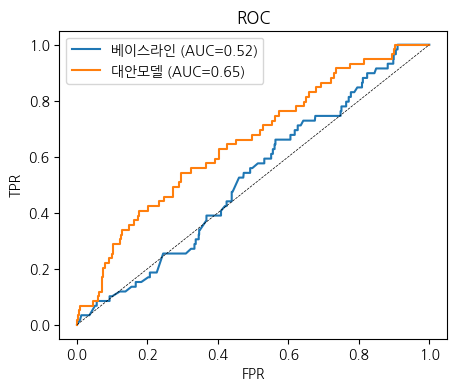

In [30]:
# [셀 6] 피처셋 — 라벨 있는(부채보유 질문대상) 가구만 모델링
BASELINE = ["age","labor_m"]
ALT      = ["age","labor_m","pension_m","fin_asset","net_worth","dsr_pct","housing_own"]
mdf = df[df["label"].notna()].copy()          # ★ 연체 라벨 있는 가구만
y = mdf["label"].astype(int)
print("모델 표본:", len(mdf), "| 연체:", int(y.sum()), f"({100*y.mean():.1f}%)")
Xtr_idx, Xte_idx = train_test_split(mdf.index, test_size=0.3, random_state=1, stratify=y)

def fit_eval(feats, name, plot=False):
    Xtr, Xte = mdf.loc[Xtr_idx, feats], mdf.loc[Xte_idx, feats]
    ytr, yte = y.loc[Xtr_idx], y.loc[Xte_idx]
    pipe = Pipeline([("imp",SimpleImputer(strategy="median")),
                     ("sc",StandardScaler()),
                     ("lr",LogisticRegression(max_iter=1000, class_weight="balanced"))]).fit(Xtr, ytr)
    p = pipe.predict_proba(Xte)[:,1]
    auc = roc_auc_score(yte, p); fpr,tpr,_ = roc_curve(yte,p); ks = float(np.max(tpr-fpr))
    print(f"[{name}] AUC={auc:.3f}  KS={ks:.3f}")
    if plot: plt.plot(fpr,tpr,label=f"{name} (AUC={auc:.2f})")
    return pipe, p, yte

plt.figure(figsize=(5,4))
base_pipe, pb, yte = fit_eval(BASELINE, "베이스라인", plot=True)
alt_pipe,  pa, yte = fit_eval(ALT,      "대안모델",  plot=True)
plt.plot([0,1],[0,1],"k--",lw=.5); plt.legend(); plt.title("ROC"); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.show()

## 킬러 지표 — 부당거절(False Rejection) 감소
동일 승인율에서, **실제 저위험(label=0) 시니어를 각 모델이 얼마나 거절하는가.**
대안모델이 덜 거절할수록 "전통 평가가 놓치는 저위험 시니어를 우리가 구제한다"가 수치로 증명된다.


In [31]:
# [셀 7] 부당거절 감소
def rejection_of_good(y_true, prob, approve_rate=0.70):
    cut = np.quantile(prob, approve_rate)      # prob=취약확률, 낮으면 승인
    approved = prob <= cut
    good = (y_true.values == 0)
    return (good & ~approved).sum() / good.sum()

rg_b = rejection_of_good(yte, pb); rg_a = rejection_of_good(yte, pa)
print(f"저위험 시니어 거절율  베이스={rg_b:.3f} → 대안={rg_a:.3f}")
print(f"➡ 부당거절 감소율: {(rg_b-rg_a)/max(rg_b,1e-9)*100:.1f}%")


저위험 시니어 거절율  베이스=0.303 → 대안=0.286
➡ 부당거절 감소율: 5.6%


## (선택) LightGBM 비교 + 중요도

LightGBM AUC: 0.677


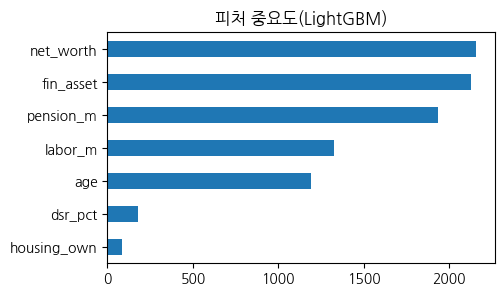

In [32]:
# [셀 8] LightGBM (없으면 자동 skip)
try:
    import lightgbm as lgb
    Xtr, Xte = mdf.loc[Xtr_idx, ALT], mdf.loc[Xte_idx, ALT]
    ytr = y.loc[Xtr_idx]
    m = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, verbose=-1).fit(Xtr, ytr)
    pg = m.predict_proba(Xte)[:,1]
    print("LightGBM AUC:", round(roc_auc_score(yte, pg), 3))
    imp = pd.Series(m.feature_importances_, index=ALT).sort_values()
    imp.plot.barh(figsize=(5,3), title="피처 중요도(LightGBM)"); plt.show()
except Exception as e:
    print("LightGBM 생략:", e)


## 계리 레이어 — 실제 KOSIS 생명표로 생존확률 가중 연금현가 (시현 님만의 해자)
완전생명표의 나이·성별 사망확률 q_x로 생존확률을 만들어 **연금소득의 생존·할인 가중 현가(annuity PV)**를 구한다.
"몇 살까지 산다"는 가정 없이 각 미래연도를 생존확률로 가중 → 감당가능 대출 규모 산출.
**`kosis_life_table_2024.csv`를 노트북 옆에 두면 실제값 사용**, 없으면 근사 폴백으로 그래도 실행됨.


In [33]:
# [셀 9] 계리 상환여력 — 실제 생명표 사용(있으면), 없으면 근사 폴백
LIFE_TABLE_PATH = "/content/drive/MyDrive/SilverPass/kosis_life_table_2024.csv"
try:
    lt = pd.read_csv(LIFE_TABLE_PATH)
    def _qx(age0, sex, horizon):
        col = {"total":"qx_total","male":"qx_male","female":"qx_female"}[sex]
        return lt[lt.age >= age0].sort_values("age")[col].values[:horizon]
    print("실제 KOSIS 생명표 로드:", lt.shape)
except Exception as e:
    print("생명표 CSV 없음 → 근사 폴백:", e)
    def _qx(age0, sex, horizon):
        ages = np.arange(age0, age0+horizon)
        return np.clip(0.0043*(1.12)**(ages-60), 0, 1)   # 실제 q60≈0.0043 근사

def survival_curve(age0, sex="total", horizon=40):
    return np.cumprod(1 - _qx(age0, sex, horizon))

def annuity_pv(monthly_pension, age0, sex="total", i=0.03):
    surv = survival_curve(age0, sex)
    disc = 1/(1+i)**np.arange(1, len(surv)+1)
    return float(np.sum(monthly_pension*12 * surv * disc))

for a in [60, 65, 68, 75]:
    print(f"{a}세 월40만원 연금 → 생존가중 현가 ≈ {annuity_pv(40,a):,.0f}만원 "
          f"(감당가능 대출 30% ≈ {annuity_pv(40,a)*0.3:,.0f}만원)")


실제 KOSIS 생명표 로드: (46, 7)
60세 월40만원 연금 → 생존가중 현가 ≈ 8,206만원 (감당가능 대출 30% ≈ 2,462만원)
65세 월40만원 연금 → 생존가중 현가 ≈ 7,182만원 (감당가능 대출 30% ≈ 2,155만원)
68세 월40만원 연금 → 생존가중 현가 ≈ 6,520만원 (감당가능 대출 30% ≈ 1,956만원)
75세 월40만원 연금 → 생존가중 현가 ≈ 4,882만원 (감당가능 대출 30% ≈ 1,465만원)


In [34]:
# [셀 9b] 노후소득 진단 — 국민연금 수급/가입현황 API + 생명표 + 물가
import requests

NPS_KEY = "f11cef5714925f73713c96a17b170bccd9292c98e5f3fccd3515f606b9ba0ae4"  # 일반(디코딩) 인증키

# mode별: (서비스, 지역오퍼레이션, 연령오퍼레이션, 연령파라미터명, 월수급/예상금액 필드)
_SVC = {
    "수급": ("NpsReciptInfoProvdServiceV2", "getReciptSttusInfoSearchV2", "getReciptAgeInfoSearchV2", "crtrAge",  "avgFnlPrvsAmt"),
    "예상": ("NpsSbscrbInfoProvdServiceV2", "getSbscrbSttusInfoSearchV2", "getSbscrbAgeInfoSearchV2", "jnngpAge", "avgAntcPnsAmt"),
}

def pension_manwon(age, mode="수급", sido=None, sex=None, pay_cls="10"):
    """월 연금액(만원). mode='수급'=실제 노령연금 수급액(시니어 권장), '예상'=가입자 예상연금.
       sido 주면 지역별(대구=27), 없으면 전국 연령별. pay_cls=10(노령)."""
    svc, op_region, op_age, age_key, amt_key = _SVC[mode]
    base = f"https://apis.data.go.kr/B552015/{svc}"
    if sido:
        params = {age_key: int(age), "ldongAddrMgplDgCd": sido}
        if sex: params["sexDvcd"] = {"male":"M","female":"F"}.get(sex, sex)
        if mode == "수급": params["payClssCd"] = pay_cls
        op = op_region
    else:
        params = {age_key: int(age)}
        if mode == "수급": params["payClssCd"] = pay_cls
        op = op_age
    params.update({"serviceKey": NPS_KEY, "dataType": "json"})
    r = requests.get(f"{base}/{op}", params=params, timeout=10); r.raise_for_status()
    it = r.json()["response"]["body"]["items"]["item"]
    it = it[0] if isinstance(it, list) else it
    val = it.get(amt_key) or it.get(amt_key + ":")   # 문서 오탈자(콜론) 방어
    return float(val) / 10000

def life_expectancy(age0, sex="total"):
    col = {"total":"ex_total","male":"ex_male","female":"ex_female"}[sex]
    row = lt[lt.age == int(age0)]
    return float(row[col].iloc[0]) if len(row) else float(lt.sort_values("age")[col].iloc[-1])

def diagnose_income(age, sex="total", need_manwon=130, sido=None, mode="수급",
                    inflation=0.023, discount=0.03):
    """예상/수급 연금 vs 필요생활비 → 월부족액 + 은퇴기간 실질 부족 누적(생존확률 가중)."""
    try:
        pension = pension_manwon(age, mode=mode, sido=sido, sex=sex)
        src = f"국민연금 {mode} API"
    except Exception as e:
        pension, src = None, f"API실패({type(e).__name__}) → 조사값(공적이전소득) 대체 필요"
    gap_m = max(0.0, need_manwon - (pension or 0))
    ex = life_expectancy(age, sex)
    surv = survival_curve(age, sex, horizon=int(ex)+1)                 # 셀9의 생존확률
    weight = [(1+inflation)**t / (1+discount)**t for t in range(len(surv))]
    total_shortfall = gap_m*12 * float(sum(s*w for s,w in zip(surv, weight)))
    return {"연금_월만원": round(pension,1) if pension else None, "출처": src,
            "필요생활비_월만원": need_manwon, "월부족_만원": round(gap_m,1),
            "기대여명_년": round(ex,1), "은퇴기간_총부족_만원": round(total_shortfall)}

# 데모: 68세 여성, 대구(27), 필요생활비 월 130만원, 실제 수급액 기준
import json
print(json.dumps(diagnose_income(68, sex="female", need_manwon=130, sido="27", mode="수급"),
                 ensure_ascii=False, indent=2))

{
  "연금_월만원": 59.1,
  "출처": "국민연금 수급 API",
  "필요생활비_월만원": 130,
  "월부족_만원": 70.9,
  "기대여명_년": 21.0,
  "은퇴기간_총부족_만원": 14626
}


## 공정성 체크 — 집단 간 성능 격차

In [35]:
# [셀 10] 공정성
te = pd.DataFrame({"y":yte.values, "p":pa, "sex":mdf.loc[Xte_idx,"sex"].values})
for s,g in te.groupby("sex"):
    if g.y.nunique()>1:
        print(f"성별={s}  AUC={roc_auc_score(g.y,g.p):.3f}  n={len(g)}")
print("\n※ 실데이터에선 장애/소득분위별 격차, 점수가 '가난 프록시'화되지 않는지도 점검")


성별=1  AUC=0.637  n=661
성별=2  AUC=0.633  n=220

※ 실데이터에선 장애/소득분위별 격차, 점수가 '가난 프록시'화되지 않는지도 점검


## 파트너 계약용 출력 형태 (미션 2의 API Contract)
파트너 UI·DID 로직이 기대할 **출력 JSON 모양**. 모델이 미완성이어도 이 함수가 같은 형태를 뱉으면 병렬 개발 가능.


In [36]:
import numpy as np
import pandas as pd

# [셀 11] score_user — 파트너에게 줄 출력 계약
def score_user(inp: dict) -> dict:
    """inp keys: age, sex, pension_m, labor_m, fin_asset, net_worth, housing_own"""
    # Create a DataFrame from the input and ensure all ALT features are present.
    # Fill missing features (like 'dsr_pct' if not provided) with NaN.
    input_df = pd.DataFrame([inp])
    X = input_df.reindex(columns=ALT, fill_value=np.nan)

    prob_vuln = float(alt_pipe.predict_proba(X)[0,1])
    alt_score = int(np.clip(900 - prob_vuln*500, 300, 900))
    grade = "A+" if alt_score>=820 else "B" if alt_score>=700 else "C"
    pv = annuity_pv(inp["pension_m"], inp["age"], sex={1:"male",2:"female"}.get(inp.get("sex"),"total"))
  # (교체) 실제 노후소득 진단 연결
    diag = diagnose_income(inp["age"], sex={1:"male",2:"female"}.get(inp.get("sex"),"total"),
                           need_manwon=inp.get("need_manwon", 130),
                           sido=inp.get("sido"), mode="수급")
    monthly_gap = diag["월부족_만원"]
    return {
        "alt_score": alt_score, "grade": grade,
        "prob_vulnerable": round(prob_vuln,3),
        "monthly_gap_manwon": monthly_gap,
        "expected_pension_manwon": diag["연금_월만원"],
        "retirement_shortfall_manwon": diag["은퇴기간_총부족_만원"],
        "affordable_loan_manwon": round(pv*0.3),
        "vc_payload": {"grade": grade, "score": alt_score, "issued_by": "SilverPassport"}
    }

import json
print(json.dumps(score_user(dict(age=68,sex=2,pension_m=40,labor_m=0,
      fin_asset=3000,net_worth=15000,housing_own=1)), ensure_ascii=False, indent=2))

{
  "alt_score": 635,
  "grade": "C",
  "prob_vulnerable": 0.529,
  "monthly_gap_manwon": 68.8,
  "expected_pension_manwon": 61.2,
  "retirement_shortfall_manwon": 14178,
  "affordable_loan_manwon": 2112,
  "vc_payload": {
    "grade": "C",
    "score": 635,
    "issued_by": "SilverPassport"
  }
}


---
### 다음 스텝
1. **미션1**: MDIS 다운로드 → 코드집으로 `COLS` 채우기 → `USE_SYNTHETIC=False` → 셀 재실행
2. 셀11의 `vc_payload`가 파트너의 **DID 발급 스키마 초안** — 메신저로 이 JSON 그대로 공유
3. 셀9의 q_x를 실제 KOSIS 생명표로 교체하면 계리 레이어 완성
